In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta
import gc 
import os 
import sys
import warnings 


In [8]:
data = pd.read_csv('../data/raw/SPY_ohlcv_1d.csv')
data['ts_event'] = pd.to_datetime(data['ts_event'])
data[data['ts_event'] >= '2022-01-01'].head()

,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
505,2022-01-03 00:00:00+00:00,35,43,15144,476.38,478.11,473.85,477.35,13196431,SPY
506,2022-01-04 00:00:00+00:00,35,43,15144,478.37,479.98,475.58,477.00,11609614,SPY
507,2022-01-05 00:00:00+00:00,35,43,15144,476.89,477.98,467.41,468.98,18574383,SPY
508,2022-01-06 00:00:00+00:00,35,43,15144,468.45,470.82,465.43,469.18,16230598,SPY
509,2022-01-07 00:00:00+00:00,35,43,15144,467.55,469.30,464.65,466.08,14619022,SPY


In [7]:
dollar = data.copy()[['ts_event']]
dollar['dollar'] = 1.0
dollar.head()

,ts_event,dollar
0,2020-01-02 00:00:00+00:00,1.0
1,2020-01-03 00:00:00+00:00,1.0
2,2020-01-06 00:00:00+00:00,1.0
3,2020-01-07 00:00:00+00:00,1.0
4,2020-01-08 00:00:00+00:00,1.0


In [18]:
def backtest(data, dollar, delay = timedelta(days = 1)):
    data = data.copy()
    dollar = dollar.copy() 
    dollar['ts_event'] = data['ts_event'] + delay 
    df = pd.merge_asof(left = data, right = dollar, on = 'ts_event', direction = 'backward')
    df['target_shrs'] = df['dollar'] / df['close']
    df['curr_shrs'] = df['target_shrs'].shift()
    df['traded_shrs'] = df['curr_shrs'].diff().combine_first(df['curr_shrs'])
    df['TWAP'] = (df['close'] + df['open'])/2

    # how much cash you spend 
    df['cash_spend'] = df['traded_shrs'] * df['TWAP']
    df['net_cash'] = df['cash_spend'].cumsum() * (-1)

    # portfolio: cash + asset 
    df['asset_value'] = df['curr_shrs'] * df['close']
    df['portfolio_value'] = df['net_cash'] + df['asset_value']
    return df
df = backtest(data, dollar)

In [19]:
# day 1: 100 ---> signal = 1  --> compute at 16:00:00 --> get it by 17:00:00 --> trade it on day2 

# df 1            df 2
# 10:00  1        10:05   3
# 11:00  2        11:05   3.5 

In [20]:
df.head()

,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,dollar,target_shrs,curr_shrs,traded_shrs,TWAP,cash_spend,net_cash,asset_value,portfolio_value
0,2020-01-02 00:00:00+00:00,35,43,15144,323.52,325.24,322.535,325.05,11807293,SPY,NaN,NaN,NaN,NaN,324.285,NaN,NaN,NaN,NaN
1,2020-01-03 00:00:00+00:00,35,43,15144,321.82,323.64,319.690,322.67,19279636,SPY,1.0,0.003099,NaN,NaN,322.245,NaN,NaN,NaN,NaN
2,2020-01-06 00:00:00+00:00,35,43,15144,320.05,323.95,319.980,323.27,11281994,SPY,1.0,0.003093,0.003099,0.003099,321.660,0.996870,-0.996870,1.001859,0.004990
3,2020-01-07 00:00:00+00:00,35,43,15144,324.10,324.13,318.720,319.44,9326614,SPY,1.0,0.003130,0.003093,-0.000006,321.770,-0.001851,-0.995019,0.988152,-0.006867
4,2020-01-08 00:00:00+00:00,35,43,15144,322.08,325.78,322.030,325.20,15896820,SPY,1.0,0.003075,0.003130,0.000037,323.640,0.012003,-1.007022,1.018032,0.011009


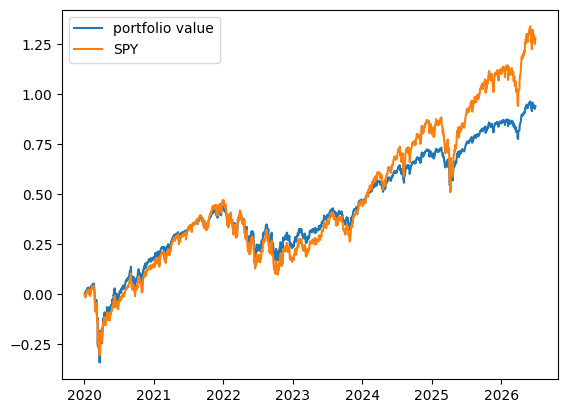

In [21]:
plt.plot(df['ts_event'], df['portfolio_value'], label = 'portfolio value')
plt.plot(data['ts_event'], data['close']/data['close'].iloc[0] - 1, label = 'SPY')
plt.legend()
plt.show()